# 03 — Korelasyon ve Regresyon

TÜBİTAK IoB projesi: **hava durumu ↔ müşteri tercihi/davranışı** ilişkisinin istatistiksel modellenmesi.

Zaman serisi analizinde (02) CCF bulguları hava etkisinin **eşzamanlı (anlık)** olduğunu gösterdi; bu notebook oturum düzeyinde çapraz-kesitsel ilişkiyi inceler.

**Veri:** `Veriler/oturum_hava_temiz_2021_sonrasi.csv` (120.749 oturum)

**Çıktı:** `Outputs/Analizler/03_korelasyon_regresyon/`


In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from scipy.stats import chi2_contingency, spearmanr, pearsonr, shapiro
from statsmodels.discrete.discrete_model import MNLogit

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
DPI = 200

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "Veriler" / "oturum_hava_temiz_2021_sonrasi.csv"
OUTPUT_DIR = PROJECT_ROOT / "Outputs" / "Analizler" / "03_korelasyon_regresyon"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

HAVA_SAYISAL = [
    "temperature_2m", "windspeed_10m", "relative_humidity_2m",
    "precipitation", "cloudcover",
]
DAVRANIS = ["toplam_miktar", "urun_sayisi", "oturum_sure_dk"]
CORR_COLS = HAVA_SAYISAL + DAVRANIS
HAVA_KATEGORIK = ["ruzgar_seviyesi", "nem_grubu", "yagis_yogunlugu", "bulut_grubu"]
LOGIT_PREDICTORS = [
    "temperature_2m", "windspeed_10m", "relative_humidity_2m", "precipitation",
]

if not DATA_PATH.exists():
    raise FileNotFoundError("Temiz veri yok. Once 00_veri_hazirlama calistirin.")

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["acilis_datetime", "kapama_datetime", "tarih", "merge_saati"],
)

# Referans masa grubu: en sik kategori (Ic Salon)
REF_MASA = df["masa_grup"].value_counts().index[0]
_masa_all = df["masa_grup"].dropna().unique().tolist()
MASA_ORDER = [REF_MASA] + [m for m in _masa_all if m != REF_MASA]

print("Veri:", df.shape)
print("Referans masa (MNLogit):", REF_MASA)
print("Masa dagilimi:\n", df["masa_grup"].value_counts())


Veri: (120749, 66)
Referans masa (MNLogit): İç Salon
Masa dagilimi:
 masa_grup
İç Salon    47052
Bahçe       37622
Paket       36075
Name: count, dtype: int64


## ADIM 1: Sürekli Değişkenler Arası Korelasyon (Pearson / Spearman)

### Neden bu yöntemi seçtik?

Sürekli hava değişkenleri (sıcaklık, rüzgar, nem, yağış) ile davranışsal çıktılar (miktar, ürün sayısı, oturum süresi) arasındaki **doğrusal ilişki yönünü ve gücünü** nicel olarak ölçmek için korelasyon analizi standart bir ilk adımdır (Cohen, 1988).

- **Pearson r**: iki değişken arasında doğrusal ilişkiyi varsayar; gözlemlerin yaklaşık normal dağıldığı durumlarda BLUE özellikleri taşır.
- **Spearman ρ**: sıra korelasyonudur; aykırı değerlere dayanıklıdır ve **monotonik** (doğrusal olmak zorunda olmayan) ilişkileri yakalar.

Restoran oturum verilerinde harcama ve süre dağılımları genellikle **çarpık (right-skewed)** olduğundan, Shapiro-Wilk normallik testi ile dağılım kontrol edilir; normallik reddedildiğinde **birincil yorum Spearman** korelasyonuna dayanır. Her iki katsayı da raporlanır; heatmap üzerinde p-değeri anlamlılık yıldızları (* p<0,05) ile işaretlenir.


Normallik testi (orneklem n=5000):
      degisken  shapiro_W      p_deger  normal_dagilim
 toplam_miktar     0.7341 4.331812e-67           False
   urun_sayisi     0.8596 4.340365e-55           False
oturum_sure_dk     0.6491 1.106759e-72           False

=> Birincil yorum: Spearman korelasyonu



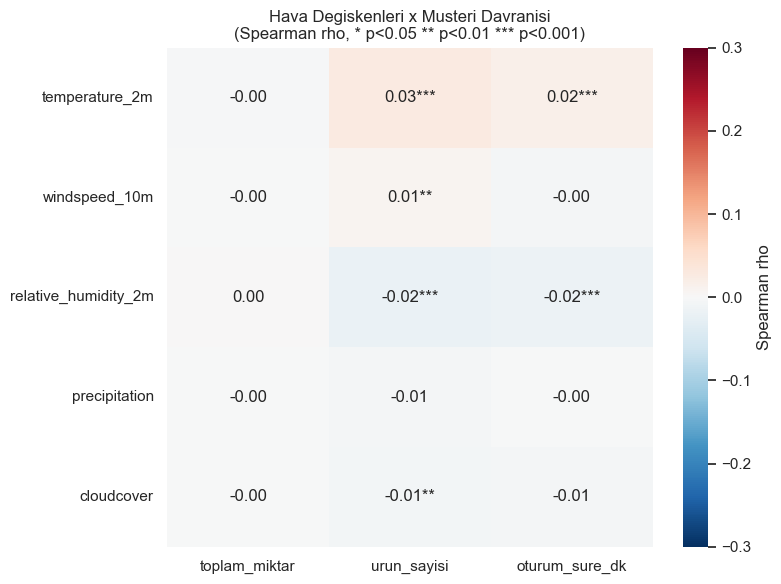

En guclu Spearman iliskileri:


,hava,davranis,spearman_rho,p_deger,anlamli_005
1,temperature_2m,urun_sayisi,0.0261,1.069287e-19,True
7,relative_humidity_2m,urun_sayisi,-0.0194,1.518487e-11,True
2,temperature_2m,oturum_sure_dk,0.0187,7.899148e-11,True
8,relative_humidity_2m,oturum_sure_dk,-0.0170,3.451055e-09,True
4,windspeed_10m,urun_sayisi,0.0081,5.053789e-03,True
13,cloudcover,urun_sayisi,-0.0078,7.077347e-03,True
14,cloudcover,oturum_sure_dk,-0.0055,5.638905e-02,False
10,precipitation,urun_sayisi,-0.0053,6.491311e-02,False


In [2]:
def corr_with_pvalues(data: pd.DataFrame, cols: list, method: str = "spearman"):
    corr = pd.DataFrame(np.eye(len(cols)), index=cols, columns=cols, dtype=float)
    pval = pd.DataFrame(np.zeros((len(cols), len(cols))), index=cols, columns=cols, dtype=float)
    for i, c1 in enumerate(cols):
        for j, c2 in enumerate(cols):
            if j < i:
                continue
            if c1 == c2:
                continue
            pair = data[[c1, c2]].dropna()
            if method == "pearson":
                r, p = pearsonr(pair[c1], pair[c2])
            else:
                r, p = spearmanr(pair[c1], pair[c2])
            corr.loc[c1, c2] = float(np.asarray(r).ravel()[0])
            corr.loc[c2, c1] = float(np.asarray(r).ravel()[0])
            pval.loc[c1, c2] = float(np.asarray(p).ravel()[0])
            pval.loc[c2, c1] = float(np.asarray(p).ravel()[0])
    return corr, pval


def sig_label(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""


# Normallik kontrolu (orneklem — buyuk n'de her zaman reddedilir)
_norm_sample = df[DAVRANIS].dropna().sample(min(5000, len(df)), random_state=42)
norm_test = []
for col in DAVRANIS:
    stat, p = shapiro(_norm_sample[col])
    norm_test.append({"degisken": col, "shapiro_W": round(stat, 4), "p_deger": p, "normal_dagilim": p >= 0.05})
norm_df = pd.DataFrame(norm_test)
norm_df.to_csv(OUTPUT_DIR / "normallik_shapiro.csv", index=False, encoding="utf-8-sig")
print("Normallik testi (orneklem n=5000):")
print(norm_df.to_string(index=False))
print("\n=> Birincil yorum: Spearman korelasyonu\n")

pearson_r, pearson_p = corr_with_pvalues(df, CORR_COLS, "pearson")
spearman_r, spearman_p = corr_with_pvalues(df, CORR_COLS, "spearman")

pearson_r.round(4).to_csv(OUTPUT_DIR / "korelasyon_pearson.csv", encoding="utf-8-sig")
pearson_p.round(6).to_csv(OUTPUT_DIR / "korelasyon_pearson_pvalues.csv", encoding="utf-8-sig")
spearman_r.round(4).to_csv(OUTPUT_DIR / "korelasyon_spearman.csv", encoding="utf-8-sig")
spearman_p.round(6).to_csv(OUTPUT_DIR / "korelasyon_spearman_pvalues.csv", encoding="utf-8-sig")

# Heatmap — Spearman (hava x davranis alt matrisi)
sub_r = spearman_r.loc[HAVA_SAYISAL, DAVRANIS]
sub_p = spearman_p.loc[HAVA_SAYISAL, DAVRANIS]

annot = sub_r.copy().astype(str)
for i in sub_r.index:
    for j in sub_r.columns:
        r = sub_r.loc[i, j]
        star = sig_label(sub_p.loc[i, j])
        annot.loc[i, j] = f"{r:.2f}{star}"

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(sub_r, annot=annot, fmt="", cmap="RdBu_r", center=0, vmin=-0.3, vmax=0.3, ax=ax,
            cbar_kws={"label": "Spearman rho"})
ax.set_title("Hava Degiskenleri x Musteri Davranisi\n(Spearman rho, * p<0.05 ** p<0.01 *** p<0.001)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "korelasyon_heatmap_spearman.png", dpi=DPI, bbox_inches="tight")
plt.show()

# En guclu hava-davranis iliskileri
pairs = []
for h in HAVA_SAYISAL:
    for d in DAVRANIS:
        pairs.append({
            "hava": h, "davranis": d,
            "spearman_rho": round(float(spearman_r.loc[h, d]), 4),
            "p_deger": float(spearman_p.loc[h, d]),
            "anlamli_005": float(spearman_p.loc[h, d]) < 0.05,
        })
pairs_df = pd.DataFrame(pairs).sort_values("spearman_rho", key=abs, ascending=False)
pairs_df.to_csv(OUTPUT_DIR / "hava_davranis_korelasyon_siralama.csv", index=False, encoding="utf-8-sig")
print("En guclu Spearman iliskileri:")
pairs_df.head(8)


## ADIM 2: Kategorik Hava Durumu ve Masa Tercihi İlişkisi (Ki-Kare Testi)

### Neden bu yöntemi seçtik?

Hocanın **"parametrelere göre gruplama"** direktifi, hava koşullarının kategorik sınıflandırmaları (`ruzgar_seviyesi`, `nem_grubu`, `yagis_yogunlugu`, `bulut_grubu`) ile nominal **masa tercihi** (İç Salon, Bahçe, Paket) arasındaki bağımlılığı test etmeyi gerektirir.

**Ki-Kare Bağımsızlık Testi (χ²)**, iki kategorik değişkenin birbirinden bağımsız olup olmadığını H₀: "hava kategorisi ile masa tercihi bağımsızdır" hipotezi altında sınar (Agresti, 2013). p < 0,05 ise kategorik hava koşulu ile masa seçimi arasında **istatistiksel olarak anlamlı ilişki** vardır. Etki büyüklüğü için **Cramér's V** (0–1) raporlanır; 0,1 / 0,3 / 0,5 eşikleri zayıf / orta / güçlü etki olarak yorumlanır.


In [3]:
def chi_square_test(data: pd.DataFrame, hava_col: str, masa_col: str = "masa_grup") -> dict:
    tab = pd.crosstab(data[hava_col], data[masa_col])
    chi2, p, dof, expected = chi2_contingency(tab)
    n = tab.values.sum()
    k = min(tab.shape)
    cramers_v = np.sqrt(chi2 / (n * (k - 1))) if k > 1 else np.nan
    min_expected = expected.min()
    return {
        "hava_degiskeni": hava_col,
        "chi2": round(float(chi2), 4),
        "dof": int(dof),
        "p_deger": float(p),
        "anlamli_005": bool(p < 0.05),
        "cramers_v": round(float(cramers_v), 4),
        "min_beklenen_frekans": round(float(min_expected), 2),
        "gozlem": int(n),
    }


chi_results = []
chi_tables = {}
for col in HAVA_KATEGORIK:
    res = chi_square_test(df, col)
    chi_results.append(res)
    tab = pd.crosstab(df[col], df["masa_grup"], margins=True)
    pct = pd.crosstab(df[col], df["masa_grup"], normalize="index") * 100
    chi_tables[col] = {"count": tab, "pct": pct.round(2)}
    tab.to_csv(OUTPUT_DIR / f"chi_crosstab_{col}.csv", encoding="utf-8-sig")
    pct.round(2).to_csv(OUTPUT_DIR / f"chi_crosstab_{col}_pct.csv", encoding="utf-8-sig")

chi_df = pd.DataFrame(chi_results).sort_values("p_deger")
chi_df.to_csv(OUTPUT_DIR / "chi_kare_ozet.csv", index=False, encoding="utf-8-sig")

print("=== Ki-Kare Bagimsizlik Testleri (Hava Kategorisi x Masa Tercihi) ===")
for row in chi_results:
    flag = "ANLAMLI" if row["anlamli_005"] else "anlamli degil"
    print(
        f"{row['hava_degiskeni']:20s} | chi2={row['chi2']:10.2f} | DoF={row['dof']} | "
        f"p={row['p_deger']:.2e} | Cramers V={row['cramers_v']:.4f} | {flag}"
    )
chi_df


=== Ki-Kare Bagimsizlik Testleri (Hava Kategorisi x Masa Tercihi) ===
ruzgar_seviyesi      | chi2=    113.48 | DoF=6 | p=3.81e-22 | Cramers V=0.0217 | ANLAMLI
nem_grubu            | chi2=   4076.06 | DoF=6 | p=0.00e+00 | Cramers V=0.1299 | ANLAMLI
yagis_yogunlugu      | chi2=    729.40 | DoF=6 | p=2.74e-154 | Cramers V=0.0550 | ANLAMLI
bulut_grubu          | chi2=   2528.76 | DoF=4 | p=0.00e+00 | Cramers V=0.1023 | ANLAMLI


,hava_degiskeni,chi2,dof,p_deger,anlamli_005,cramers_v,min_beklenen_frekans,gozlem
1,nem_grubu,4076.0564,6,0.000000e+00,True,0.1299,1720.26,120749
3,bulut_grubu,2528.7631,4,0.000000e+00,True,0.1023,7881.59,120749
2,yagis_yogunlugu,729.4027,6,2.738056e-154,True,0.0550,33.76,120749
0,ruzgar_seviyesi,113.4772,6,3.808605e-22,True,0.0217,4110.94,120749


## ADIM 3: Müşteri Tercihini Tahminleme (Çoklu Lojistik Regresyon)

### Neden bu yöntemi seçtik?

Ki-Kare testi yalnızca **ilişkinin varlığını** kanıtlar; etkinin **yönünü, büyüklüğünü ve kontrol edilmiş koşullu etkisini** ölçemez. **Çok sınıflı lojistik regresyon (Multinomial Logit)**, bağımlı değişkenin üç kategorili masa tercihini, sürekli hava göstergeleri (sıcaklık, rüzgar, nem, yağış) koşullu olarak modelleyerek her bir hava faktörünün **log-odds** üzerindeki katsayısını tahmin eder (Hosmer et al., 2013).

Referans kategori olarak en sık görülen masa grubu (**İç Salon**) seçilmiştir; diğer kategoriler (Bahçe, Paket) referansa göre yorumlanır. **Odds Ratio (OR) = exp(β)** ile yorum: "Sıcaklık 1°C arttığında Bahçe seçme odds'u OR kat değişir." Bu çerçeve, CCF analizindeki **anlık (eşzamanlı) hava etkisi** bulgusuyla tutarlıdır — oturum anındaki hava koşulları tercih olasılığını doğrudan etkiler.


In [4]:
# MNLogit icin veri hazirligi
model_df = df[LOGIT_PREDICTORS + ["masa_grup"]].dropna().copy()
model_df["masa_grup"] = pd.Categorical(model_df["masa_grup"], categories=MASA_ORDER, ordered=True)
y_codes = model_df["masa_grup"].cat.codes  # 0 = referans (Ic Salon)
X = sm.add_constant(model_df[LOGIT_PREDICTORS].astype(float))

print(f"MNLogit gozlem: {len(model_df):,} | Referans: {MASA_ORDER[0]}")
print("Kategori kodlari:", dict(enumerate(MASA_ORDER)))

mnlogit = MNLogit(y_codes, X)
# Tam veri seti — quasi-Newton
mn_result = mnlogit.fit(method="lbfgs", maxiter=200, disp=False)

# Katsayilar ve odds ratio (params: satir=predictor, sutun=non-ref kategori)
coef_rows = []
for j, masa in enumerate(MASA_ORDER[1:]):
    for pred in mn_result.params.index:
        coef_rows.append({
            "masa_kategori": masa,
            "degisken": pred,
            "katsayi": float(mn_result.params.loc[pred, j]),
            "std_hata": float(mn_result.bse.loc[pred, j]),
            "z": float(mn_result.tvalues.loc[pred, j]),
            "p_deger": float(mn_result.pvalues.loc[pred, j]),
            "odds_ratio": float(np.exp(mn_result.params.loc[pred, j])),
            "anlamli_005": float(mn_result.pvalues.loc[pred, j]) < 0.05,
        })
coef_df = pd.DataFrame(coef_rows)
coef_df.to_csv(OUTPUT_DIR / "mnlogit_katsayilar_odds.csv", index=False, encoding="utf-8-sig")

print("\n=== Multinomial Logit — Ozet ===")
print(mn_result.summary())

bahce_label = next(m for m in MASA_ORDER if "Bah" in m)
paket_label = next(m for m in MASA_ORDER if "Paket" in m)


def top_predictor(sub_df, masa_name):
    sub = sub_df[sub_df["masa_kategori"] == masa_name].copy()
    sub = sub[sub["degisken"] != "const"]
    sub["abs_log_or"] = np.abs(np.log(sub["odds_ratio"].replace(0, np.nan)))
    return sub.sort_values("abs_log_or", ascending=False)


bahce_effects = top_predictor(coef_df, bahce_label)
paket_effects = top_predictor(coef_df, paket_label)

print(f"\n--- {bahce_label} vs {REF_MASA} (referans) ---")
for _, row in bahce_effects.iterrows():
    sig = " *" if row["anlamli_005"] else ""
    print(f"  {row['degisken']:25s} OR={row['odds_ratio']:.4f}  p={row['p_deger']:.2e}{sig}")

print(f"\n--- {paket_label} vs {REF_MASA} ---")
for _, row in paket_effects.iterrows():
    sig = " *" if row["anlamli_005"] else ""
    print(f"  {row['degisken']:25s} OR={row['odds_ratio']:.4f}  p={row['p_deger']:.2e}{sig}")

top_bahce = bahce_effects.iloc[0]
top_paket = paket_effects.iloc[0]
print(f"\nBahce tercihini en guclu etkileyen faktor: {top_bahce['degisken']} "
      f"(OR={top_bahce['odds_ratio']:.4f})")
print(f"Paket tercihini en guclu etkileyen faktor: {top_paket['degisken']} "
      f"(OR={top_paket['odds_ratio']:.4f})")

coef_df.head(12)


MNLogit gozlem: 120,749 | Referans: İç Salon
Kategori kodlari: {0: 'İç Salon', 1: 'Bahçe', 2: 'Paket'}



=== Multinomial Logit — Ozet ===


                          MNLogit Regression Results                          
Dep. Variable:                      y   No. Observations:               120749
Model:                        MNLogit   Df Residuals:                   120739
Method:                           MLE   Df Model:                            8
Date:                Sun, 28 Jun 2026   Pseudo R-squ.:                 0.05395
Time:                        13:56:42   Log-Likelihood:            -1.2469e+05
converged:                       True   LL-Null:                   -1.3180e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 y=1       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -2.5918      0.061    -42.525      0.000      -2.711      -2.472
temperature_2m           0.1140      0.001     90.205      0.000       0.112       0.117
windspeed_10

,masa_kategori,degisken,katsayi,std_hata,z,p_deger,odds_ratio,anlamli_005
0,Bahçe,const,-2.591788,0.060947,-42.525450,0.000000e+00,0.074886,True
1,Bahçe,temperature_2m,0.114029,0.001264,90.204538,0.000000e+00,1.120784,True
2,Bahçe,windspeed_10m,-0.009168,0.001026,-8.932838,4.152186e-19,0.990874,True
3,Bahçe,relative_humidity_2m,0.007064,0.000638,11.076729,1.627086e-28,1.007089,True
4,Bahçe,precipitation,-0.123832,0.022721,-5.450035,5.035983e-08,0.883528,True
5,Paket,const,-0.738925,0.055548,-13.302422,2.240909e-40,0.477627,True
6,Paket,temperature_2m,0.023194,0.001119,20.719379,2.316561e-95,1.023465,True
7,Paket,windspeed_10m,-0.005078,0.000966,-5.254973,1.480465e-07,0.994935,True
8,Paket,relative_humidity_2m,0.002823,0.000601,4.698858,2.616203e-06,1.002827,True
9,Paket,precipitation,0.031805,0.017194,1.849810,6.434087e-02,1.032316,False


## ADIM 4: Çıktılar ve Raporlama

Tüm istatistiksel sonuçlar CSV/JSON olarak arşivlenir; korelasyon heatmap yüksek çözünürlüklü PNG formatında kaydedilir.


In [5]:
def _json_safe(obj):
    if isinstance(obj, dict):
        return {k: _json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_json_safe(v) for v in obj]
    if isinstance(obj, (np.bool_, bool)):
        return bool(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    return obj


# Anlamli ki-kare ve regresyon bulgulari
anlamli_chi = chi_df[chi_df["anlamli_005"]].to_dict(orient="records")
anlamli_logit = coef_df[(coef_df["anlamli_005"]) & (coef_df["degisken"] != "const")].to_dict(orient="records")

# En guclu spearman (hava-davranis)
top_corr = pairs_df[pairs_df["anlamli_005"]].head(5).to_dict(orient="records")

ozet = {
    "kaynak": DATA_PATH.name,
    "gozlem_sayisi": int(len(df)),
    "normallik_testi": norm_test,
    "birincil_korelasyon_yontemi": "spearman",
    "en_guclu_spearman_iliskiler": top_corr,
    "chi_kare": chi_results,
    "anlamli_chi_kare": anlamli_chi,
    "mnlogit_referans_masa": REF_MASA,
    "mnlogit_pseudo_r2": round(float(mn_result.prsquared), 4),
    "mnlogit_llf": round(float(mn_result.llf), 2),
    "bahce_en_guclu_faktor": {
        "degisken": top_bahce["degisken"],
        "odds_ratio": round(float(top_bahce["odds_ratio"]), 4),
        "p_deger": float(top_bahce["p_deger"]),
        "anlamli": bool(top_bahce["anlamli_005"]),
    },
    "paket_en_guclu_faktor": {
        "degisken": top_paket["degisken"],
        "odds_ratio": round(float(top_paket["odds_ratio"]), 4),
        "p_deger": float(top_paket["p_deger"]),
        "anlamli": bool(top_paket["anlamli_005"]),
    },
    "anlamli_mnlogit_katsayilari": anlamli_logit,
}

with open(OUTPUT_DIR / "korelasyon_regresyon_ozet.json", "w", encoding="utf-8") as f:
    json.dump(_json_safe(ozet), f, ensure_ascii=False, indent=2)

print("=== KORELASYON VE REGRESYON ANALIZI TAMAMLANDI ===")
print(f"Anlamli chi-kare testi: {len(anlamli_chi)} / {len(chi_results)}")
print(f"Anlamli MNLogit katsayisi: {len(anlamli_logit)}")
print(f"Bahce icin baskin hava faktoru: {ozet['bahce_en_guclu_faktor']['degisken']} "
      f"(OR={ozet['bahce_en_guclu_faktor']['odds_ratio']})")
print("\nCikti:", OUTPUT_DIR.resolve())


=== KORELASYON VE REGRESYON ANALIZI TAMAMLANDI ===
Anlamli chi-kare testi: 4 / 4
Anlamli MNLogit katsayisi: 7
Bahce icin baskin hava faktoru: precipitation (OR=0.8835)

Cikti: C:\Users\BUSRA\Documents\GitHub\IoBDataAnalysis\Outputs\Analizler\03_korelasyon_regresyon
